In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans # Here is where you import the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
#creating path for data import 
path = r'/Users/thomaskimber/Desktop/Task 7'

In [3]:
# importing UFC data csv 
df = pd.read_csv(os.path.join(path, 'ufc_data.csv' ), index_col = False)

In [4]:
df.shape

(6012, 144)

In [11]:
# Example engineered numeric features (use the columns we discussed)
df['avg_age'] = (df['B_age'] + df['R_age']) / 2
df['age_gap'] = (df['B_age'] - df['R_age']).abs()
df['avg_weight_lbs'] = (df['B_Weight_lbs'] + df['R_Weight_lbs']) / 2
df['avg_height_cm'] = (df['B_Height_cms'] + df['R_Height_cms']) / 2
df['avg_reach_cm'] = (df['B_Reach_cms'] + df['R_Reach_cms']) / 2
df['avg_sig_str_pct'] = (df['B_avg_SIG_STR_pct'] + df['R_avg_SIG_STR_pct']) / 2
df['avg_td_pct'] = (df['B_avg_TD_pct'] + df['R_avg_TD_pct']) / 2
df['avg_ctrl_sec'] = (df['B_avg_CTRL_time(seconds)'] + df['R_avg_CTRL_time(seconds)']) / 2
df['avg_time_fought_sec'] = (df['B_total_time_fought(seconds)'] + df['R_total_time_fought(seconds)']) / 2
df['avg_wins'] = (df['B_wins'] + df['R_wins']) / 2

# Pick the feature list you want to include in clustering
features = [
    'avg_age','age_gap','avg_weight_lbs','avg_height_cm','avg_reach_cm',
    'avg_sig_str_pct','avg_td_pct','avg_ctrl_sec','avg_time_fought_sec','avg_wins'
]

# Create a working numeric dataframe (may contain NaNs)
data = df[features].copy()
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   avg_age              5817 non-null   float64
 1   age_gap              5817 non-null   float64
 2   avg_weight_lbs       6003 non-null   float64
 3   avg_height_cm        6000 non-null   float64
 4   avg_reach_cm         4964 non-null   float64
 5   avg_sig_str_pct      4316 non-null   float64
 6   avg_td_pct           4316 non-null   float64
 7   avg_ctrl_sec         4316 non-null   float64
 8   avg_time_fought_sec  4316 non-null   float64
 9   avg_wins             6012 non-null   float64
dtypes: float64(10)
memory usage: 469.8 KB


,avg_age,age_gap,avg_weight_lbs,avg_height_cm,avg_reach_cm,avg_sig_str_pct,avg_td_pct,avg_ctrl_sec,avg_time_fought_sec,avg_wins
0,29.0,4.0,135.0,167.64,173.99,0.460000,0.165000,19.500000,348.750000,1.0
1,30.0,4.0,195.0,185.42,190.50,0.618437,0.353125,197.828125,662.421875,3.0
2,30.0,4.0,252.5,187.96,190.50,NaN,NaN,NaN,NaN,2.0
3,26.5,3.0,115.0,156.21,157.48,NaN,NaN,NaN,NaN,0.0
4,36.0,14.0,135.0,173.99,177.80,0.469351,0.348359,265.767578,819.190430,4.5


In [12]:
# Impute missing values with the median (keeps shape/index)
imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(
    imputer.fit_transform(data),
    columns=features,
    index=data.index
)

# Standardize so features contribute equally
scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data_imputed),
    columns=features,
    index=data_imputed.index
)

# quick check
data_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
avg_age,6012.0,-4.727497e-16,1.000083,-3.034536,-0.630494,0.010583,0.651661,5.139205
age_gap,6012.0,-1.229149e-16,1.000083,-1.317639,-0.679132,-0.359878,0.597884,6.025201
avg_weight_lbs,6012.0,2.647398e-16,1.000083,-1.570340,-0.723283,-0.017403,0.406126,8.876691
avg_height_cm,6012.0,-2.798678e-15,1.000083,-3.118612,-0.613556,0.012709,0.795539,3.300595
avg_reach_cm,6012.0,-3.233608e-15,1.000083,-3.381562,-0.498985,0.077530,0.654046,3.104236
avg_sig_str_pct,6012.0,-1.418249e-16,1.000083,-5.753707,-0.442031,-0.029690,0.405317,5.446892
avg_td_pct,6012.0,3.309248e-16,1.000083,-1.772258,-0.552821,-0.095532,0.411773,4.324927
avg_ctrl_sec,6012.0,-3.781997e-17,1.000083,-1.577705,-0.559306,-0.164823,0.296664,7.120095
avg_time_fought_sec,6012.0,1.796449e-16,1.000083,-3.603899,-0.432116,0.048306,0.486739,4.516437
avg_wins,6012.0,3.781997e-17,1.000083,-1.019339,-0.697882,-0.376424,0.587949,5.249084


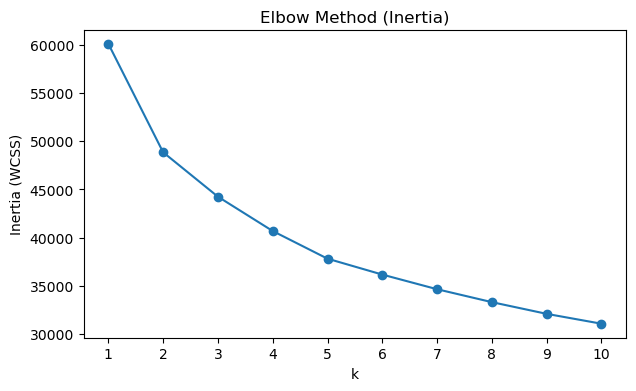

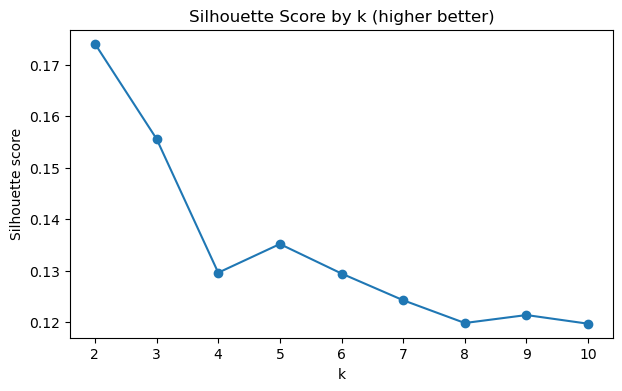

In [15]:
# Elbow (inertia) plot
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(data_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method (Inertia)')
plt.xticks(K_range)
plt.show()

# Silhouette scores for k >= 2 (helps decide)
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(data_scaled)
    sil_scores.append(silhouette_score(data_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(range(2,11), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score by k (higher better)')
plt.show()


In [20]:
# set this after inspection
k_opt = 4   

kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=42)
labels = kmeans.fit_predict(data_scaled)

# Attach labels to the rows we clustered (preserves original df length)
df.loc[data_scaled.index, 'cluster'] = labels.astype(int)

# Quick counts
print(df['cluster'].value_counts(dropna=False))


cluster
0.0    2193
3.0    1513
2.0    1426
1.0     880
Name: count, dtype: int64


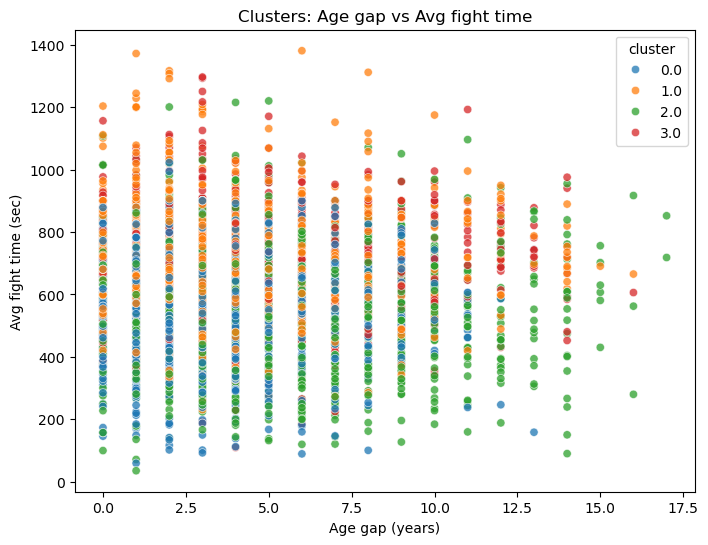

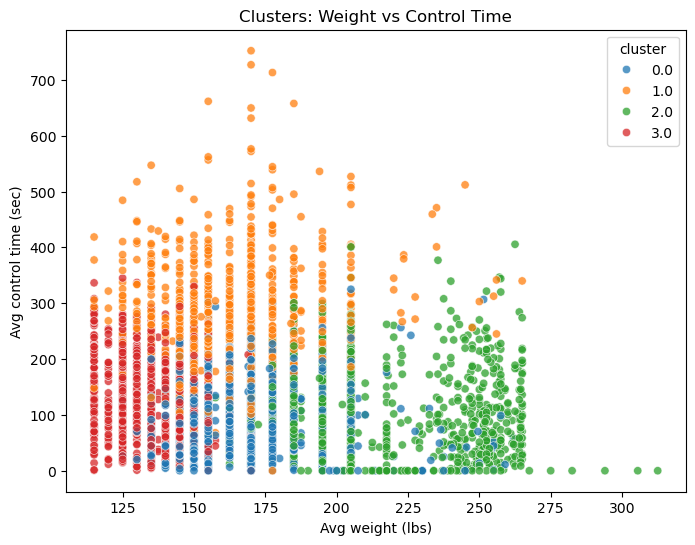

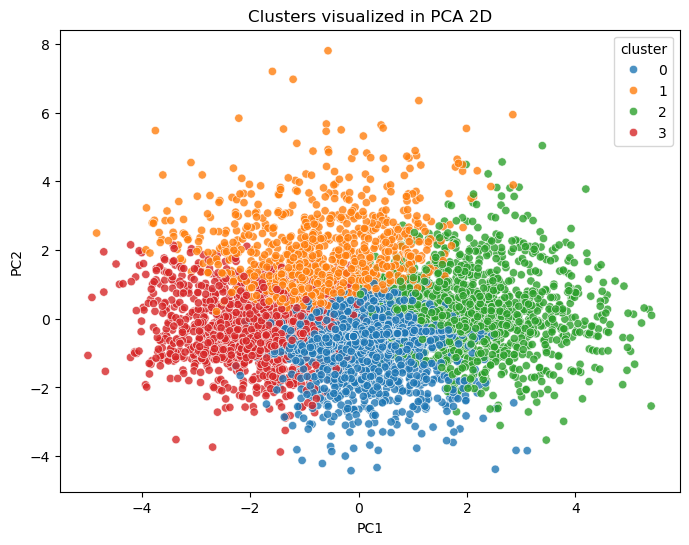

PCA explained variance ratios: [0.29114835 0.17293257]


In [21]:
# A) Scatter plot: Age gap vs fight time
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.loc[data_scaled.index],
    x='age_gap', y='avg_time_fought_sec',
    hue='cluster', palette='tab10', alpha=0.75
)
plt.xlabel('Age gap (years)')
plt.ylabel('Avg fight time (sec)')
plt.title('Clusters: Age gap vs Avg fight time')
plt.legend(title='cluster')
plt.show()

# B) Scatter plot: Avg weight vs avg control time
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.loc[data_scaled.index],
    x='avg_weight_lbs', y='avg_ctrl_sec',
    hue='cluster', palette='tab10', alpha=0.75
)
plt.xlabel('Avg weight (lbs)')
plt.ylabel('Avg control time (sec)')
plt.title('Clusters: Weight vs Control Time')
plt.legend(title='cluster')
plt.show()

# C) PCA 2D overview of clusters
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(pcs, columns=['PC1','PC2'], index=data_scaled.index)
pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab10', alpha=0.8)
plt.title('Clusters visualized in PCA 2D')
plt.show()

print("PCA explained variance ratios:", pca.explained_variance_ratio_)


Here, we can see again that there’s no pattern to the age vs time of a fight. However, we can see some clustering in weight and length of fight, which we could delve into further. Deftly heavier fighters fight for less, and the two clusters in the middle would be interesting to explore further. We could see if a style of fighter in the middle can determine the length of the fight.

In [22]:
cluster_summary = df.loc[data_scaled.index].groupby('cluster')[features].agg(['count','mean','median','std'])
pd.set_option("display.max_columns", 200)
cluster_summary


avg_age                             age_gap                   \
          count       mean median       std   count      mean median   
cluster                                                                
0.0        2061  27.805677   28.0  2.459815    2061  3.485201    3.0   
1.0         878  29.184510   29.0  2.806697     878  4.011390    3.0   
2.0        1369  32.205990   32.0  2.906550    1369  5.139518    5.0   
3.0        1509  29.411199   29.5  2.767529    1509  4.298873    4.0   

                  avg_weight_lbs                               avg_height_cm  \
              std          count        mean median        std         count   
cluster                                                                        
0.0      2.708025           2184  171.963599  170.0  23.018897          2181   
1.0      3.116493            880  163.150568  162.5  21.532730           880   
2.0      3.569522           1426  209.974053  205.0  34.087241          1426   
3.0      3.192976           1513  135.923001  135.0  12.548472          1513   

                                      avg_reach_cm                      \
               mean  median       std        count        mean  median   
cluster                                                                  
0.0      180.955493  180.34  4.766730         1497  186.047789  185.42   
1.0      177.804330  177.80  6.073206          816  182.635650  182.88   
2.0      187.015070  186.69  4.819966         1242  192.853897  193.04   
3.0      169.190357  168.91  4.722662         1409  172.423456  173.99   

                  avg_sig_str_pct                               avg_td_pct  \
              std           count      mean    median       std      count   
cluster                                                                      
0.0      4.967350            1136  0.415087  0.415254  0.089376       1136   
1.0      7.207141             880  0.489258  0.485029  0.085886        880   
2.0      5.892921            1218  0.493115  0.486562  0.093181       1218   
3.0      6.085831            1082  0.428303  0.425632  0.074636       1082   

                                      avg_ctrl_sec                          \
             mean    median       std        count        mean      median   
cluster                                                                      
0.0      0.229642  0.209650  0.171335         1136   96.238929   89.646484   
1.0      0.496156  0.488496  0.159935          880  277.039296  265.790039   
2.0      0.239299  0.222422  0.167685         1218  104.963383   97.301267   
3.0      0.270000  0.250591  0.155725         1082  122.096687  114.038086   

                   avg_time_fought_sec                                      \
               std               count        mean      median         std   
cluster                                                                      
0.0      61.774713                1136  563.068401  570.503174  178.140727   
1.0      98.644664                 880  735.140365  733.181885  166.183908   
2.0      70.665043                1218  546.145323  546.326965  192.127720   
3.0      68.003455                1082  706.036979  712.891602  166.305450   

        avg_wins                             
           count      mean median       std  
cluster                                      
0.0         2193  1.568855    1.0  1.765844  
1.0          880  4.378977    3.5  3.124978  
2.0         1426  5.139551    4.5  3.614370  
3.0         1513  2.935228    2.0  2.772414

We can now discern certain correlations between the fighter’s characteristics and the duration of their fights. The next logical step would be to delve deeper into other factors beyond weight and age to ascertain whether these variables influence the length of the fight. 